# Análise Exploratória - Ibovespa x Selic x BTG
## Este notebook explora a relação entre o desempenho do Ibovespa, Selic e BTG em 2025, buscando entender as correlações, volatidiade e demais padrões.


### Importação e Transformação
Importar as bibliotecas e as bases de dados e transformar os arquivos csv em parquet. Nesta análise não seria necessário, mas é algo importante em projetos com base de dados grandes

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df_ibov = pd.read_csv("data/ibovespa.csv")
df_selic = pd.read_csv("data/selic.csv")
df_merged = pd.read_csv("data/base_integrada.csv")

In [59]:
df_merged["data"] = pd.to_datetime(df_merged["data"])
# Converte a coluna "data" de texto (string) para o tipo datetime (data real)
# Permitindo operações temporais, como filtrar por mês, calcular médias móveis, ou plotar gráficos de série temporal.

In [60]:
# Transformando de csv para parquet
df_ibov.to_parquet("data/ibovespa.parquet", index=False)
df_selic.to_parquet("data/selic.parquet", index=False)
df_merged.to_parquet("data/base_integrada.parquet", index=False) #significa que o índice (as linhas numeradas ou datas) não será salvo no arquivo — apenas as colunas.


### Diagnóstico Inicial dos Dados

In [61]:
# Ver estrutura e tipos de dados
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   data         250 non-null    datetime64[us]
 1   ibov_close   250 non-null    float64       
 2   High         250 non-null    float64       
 3   Low          250 non-null    float64       
 4   Open         250 non-null    float64       
 5   Volume       250 non-null    int64         
 6   ibov_return  249 non-null    float64       
 7   valor        250 non-null    float64       
 8   btg_close    250 non-null    float64       
 9   btg_return   249 non-null    float64       
dtypes: datetime64[us](1), float64(8), int64(1)
memory usage: 19.7 KB


In [62]:
# Ver estatísticas básicas (média, desvio padrão, mínimo, máximo)
df_merged.describe()

,data,ibov_close,High,Low,Open,Volume,ibov_return,valor,btg_close,btg_return
count,250,250.000000,250.000000,250.000000,250.000000,2.500000e+02,249.000000,250.000000,250.000000,249.000000
mean,2025-07-01 21:12:57.600000,138060.216000,138882.616000,137142.668000,137897.420000,9.132260e+06,0.001226,14.423000,39.789602,0.002975
min,2025-01-02 00:00:00,118533.000000,119451.000000,118223.000000,118534.000000,2.114300e+06,-0.043094,12.250000,25.485979,-0.079058
25%,2025-04-02 06:00:00,130910.750000,131526.500000,130089.500000,130559.000000,7.529200e+06,-0.004066,14.250000,33.330214,-0.007159
50%,2025-07-03 12:00:00,136934.000000,137653.500000,136068.000000,136826.000000,8.832100e+06,0.001181,15.000000,38.956528,0.002158
75%,2025-09-29 18:00:00,143864.500000,144528.500000,143391.000000,143591.250000,1.022280e+07,0.005885,15.000000,45.901381,0.014021
max,2025-12-30 00:00:00,164456.000000,165036.000000,161759.000000,164461.000000,2.487380e+07,0.031178,15.000000,55.415588,0.131184
std,NaN,10982.231195,10963.906344,10934.256712,10941.690912,2.517941e+06,0.009582,0.871124,7.388157,0.019021


In [63]:
# Ver primeiras linhas
df_merged.head()

,data,ibov_close,High,Low,Open,Volume,ibov_return,valor,btg_close,btg_return
0,2025-01-02,120125.0,120782.0,119120.0,120283.0,9373600,NaN,12.25,25.848433,NaN
1,2025-01-03,118533.0,120356.0,118404.0,120125.0,9804400,-0.013253,12.25,25.485979,-0.014022
2,2025-01-06,120022.0,120322.0,118534.0,118534.0,9685600,0.012562,12.25,26.424383,0.036820
3,2025-01-07,121163.0,121713.0,120022.0,120022.0,11116400,0.009507,12.25,26.894367,0.017786
4,2025-01-08,119625.0,121160.0,119351.0,121160.0,10230700,-0.012694,12.25,26.779268,-0.004280


## Análise Explorátria
### Agora vamos análisar os gráficos e obter informações mais detalhadas que podem interferir a gestão dos portfólios tanto da empresa BTG Pactual quanto de seus clientes. Inicialmente, analisamos os dados do IBOV e Selic e, ao final, adicionamos os retornos do BTG Pactual para compará-los, buscando possíveis outliers e suas justificativas.

## 📈 Retorno Acumulado do Ibovespa em 2025

Nesta etapa da análise exploratória, vamos observar o **comportamento do Ibovespa ao longo de 2025**, calculando seu **retorno acumulado**.  
Esse indicador mostra quanto o índice valorizou (ou desvalorizou) ao longo do tempo, considerando o efeito composto dos retornos diários.  

O objetivo é entender **a tendência geral do mercado brasileiro** durante o ano e identificar períodos de maior crescimento ou correção.  
Esse tipo de análise é essencial para avaliar o desempenho dos portfólios e comparar o comportamento do índice com o de ativos específicos, como as ações do **BTG Pactual**.


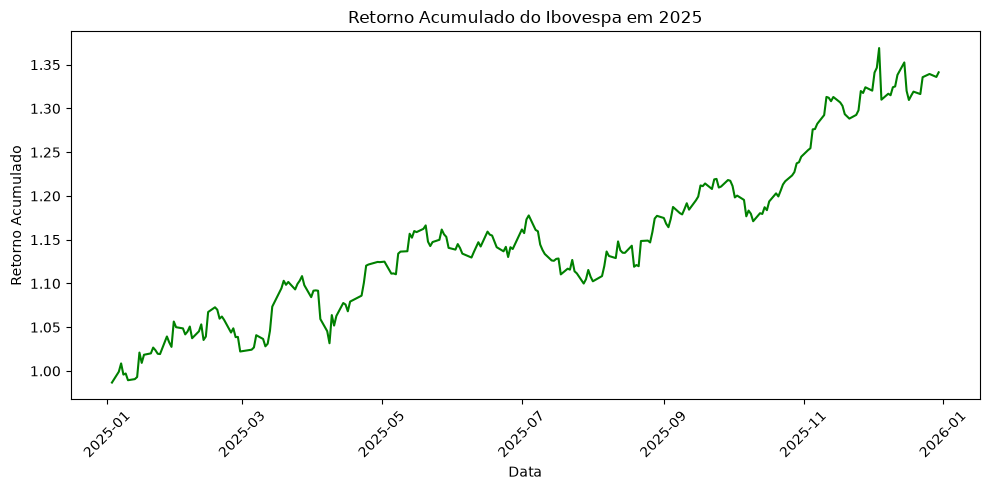

In [64]:
df_merged["retorno_acumulado"] = (1 + df_merged["ibov_return"]).cumprod()

plt.figure(figsize=(10,5))
sns.lineplot(data=df_merged, x="data", y="retorno_acumulado", color="green")
plt.title("Retorno Acumulado do Ibovespa em 2025")
plt.xlabel("Data")
plt.ylabel("Retorno Acumulado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 📊 Evolução do Ibovespa e da Selic em 2025

Nesta etapa, analisamos a **relação entre o desempenho do Ibovespa e a taxa Selic ao longo de 2025**.  
O objetivo é observar como o principal índice da bolsa brasileira se comportou diante das variações da taxa básica de juros.  

A Selic é um dos principais instrumentos de política monetária do Banco Central e influencia diretamente o mercado financeiro:  
- Juros mais altos tendem a **reduzir o apetite por risco**, pressionando o mercado acionário.  
- Juros mais baixos, por outro lado, **estimulam investimentos em ações** e ativos de maior retorno.  

O gráfico a seguir apresenta as duas curvas — o **Ibovespa (em azul)** e a **Selic (em vermelho)** — permitindo visualizar se há relação entre os movimentos de ambos durante o ano.

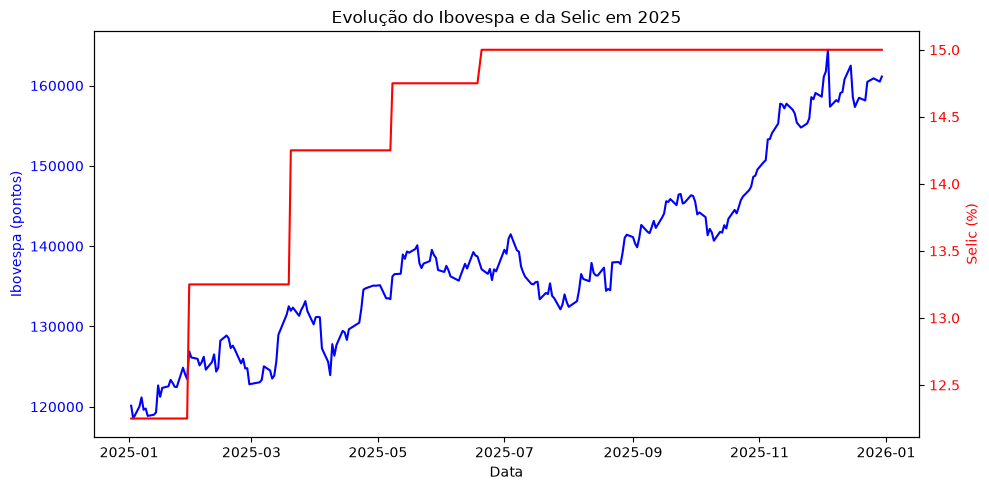

In [65]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Linha do Ibovespa (eixo da esquerda)
sns.lineplot(data=df_merged, x="data", y="ibov_close", color="blue", ax=ax1)
ax1.set_xlabel("Data")
ax1.set_ylabel("Ibovespa (pontos)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Cria segundo eixo Y (à direita)
ax2 = ax1.twinx()
sns.lineplot(data=df_merged, x="data", y="valor", color="red", ax=ax2)
ax2.set_ylabel("Selic (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Evolução do Ibovespa e da Selic em 2025")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 💡 Interpretação do gráfico

O gráfico mostra que, **mesmo com a Selic em trajetória de alta**, o **Ibovespa manteve uma tendência positiva** ao longo de 2025.  
Isso indica que o mercado acionário brasileiro **resistiu bem ao aperto monetário**, impulsionado por resultados corporativos sólidos e expectativas de crescimento econômico.  

A **Selic subiu gradualmente de cerca de 12,5% para 15%**, refletindo o esforço do Banco Central para conter pressões inflacionárias.  
Apesar disso, o **Ibovespa avançou de aproximadamente 120 mil para mais de 160 mil pontos**, mostrando **confiança dos investidores** e **forte desempenho de setores como financeiro e commodities**.  

Em resumo, o gráfico evidencia que **a alta dos juros não impediu o avanço do mercado**, sugerindo um cenário de **otimismo moderado e resiliência** da bolsa brasileira em 2025.

---

## 📊 Volatilidade do Ibovespa (Janela de 30 dias)

Nesta etapa, analisamos a **volatilidade do Ibovespa ao longo de 2025**, calculada com uma **janela móvel de 30 dias**.  
A volatilidade mede o **nível de oscilação dos retornos diários** e é um dos principais indicadores de risco no mercado financeiro.  

O objetivo é identificar **períodos de maior instabilidade** e entender como eventos econômicos e corporativos impactaram o comportamento do índice.  
Essa análise é essencial para avaliar o **grau de incerteza** enfrentado pelos investidores e a **sensibilidade do mercado** a mudanças na política monetária e nas expectativas macroeconômicas.

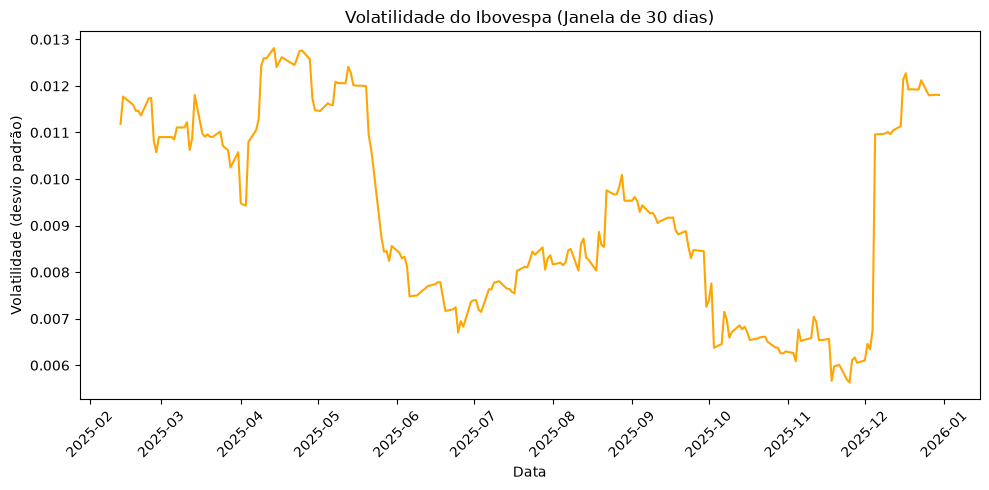

In [66]:
df_merged["volatilidade_30d"] = df_merged["ibov_return"].rolling(30).std()

plt.figure(figsize=(10,5))
sns.lineplot(data=df_merged, x="data", y="volatilidade_30d", color="orange")
plt.title("Volatilidade do Ibovespa (Janela de 30 dias)")
plt.xlabel("Data")
plt.ylabel("Volatilidade (desvio padrão)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 💡 Interpretação do gráfico

O gráfico mostra que o **Ibovespa apresentou variações moderadas de volatilidade ao longo de 2025**, com **picos mais acentuados em abril e dezembro**.  
Esses aumentos refletem momentos de **maior incerteza no mercado**, possivelmente associados à divulgação de resultados corporativos e decisões do Banco Central sobre a Selic.  

Durante o **segundo semestre**, observa-se uma **redução gradual da volatilidade**, indicando **maior estabilidade e confiança dos investidores**.  
O leve aumento em dezembro pode estar relacionado à **realização de lucros e ajustes de portfólio** típicos do encerramento do ano.  

Em síntese, o Ibovespa manteve um **nível de risco controlado**, com oscilações pontuais que refletem o comportamento natural de um mercado em expansão, mas ainda sensível às condições macroeconômicas.

---

## 📊 Ibovespa vs Selic (colorido pelos retornos)

Nesta etapa, analisamos a **relação entre o nível da taxa Selic e o desempenho do Ibovespa em 2025**, utilizando um gráfico de dispersão.  
Cada ponto representa um dia de negociação, com o **eixo X mostrando a Selic (%)** e o **eixo Y o fechamento do Ibovespa (pontos)**.  
A cor dos pontos indica o **retorno diário do índice**, permitindo visualizar se há padrões de comportamento conforme os juros variam.  

O objetivo é identificar se **mudanças na taxa de juros influenciam diretamente o desempenho do mercado acionário**, e se há tendência de maior ou menor retorno em determinados patamares da Selic.

---

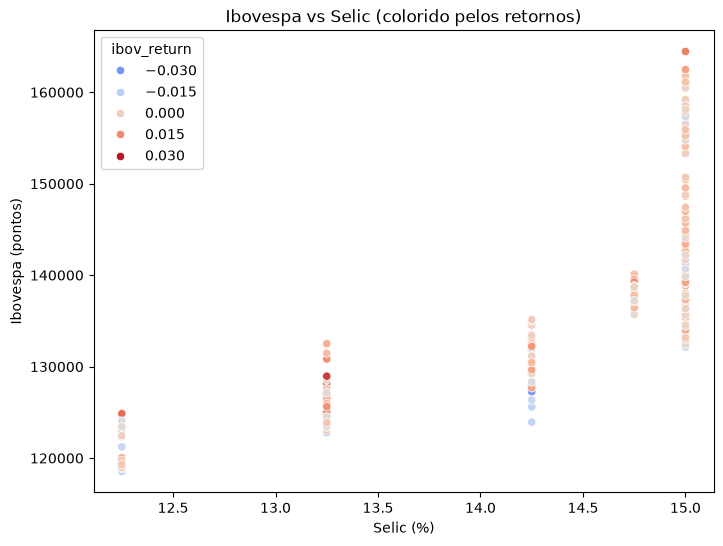

In [67]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_merged, x="valor", y="ibov_close", hue="ibov_return", palette="coolwarm")
plt.title("Ibovespa vs Selic (colorido pelos retornos)")
plt.xlabel("Selic (%)")
plt.ylabel("Ibovespa (pontos)")
plt.show()



### 💡 Interpretação do gráfico

O gráfico mostra que **não há correlação direta entre o nível da Selic e o valor do Ibovespa** durante 2025 — os pontos estão dispersos, sem uma tendência clara.  
Mesmo com a **Selic subindo gradualmente**, o **Ibovespa manteve trajetória de alta**, o que indica **resiliência do mercado** frente ao aperto monetário.  

As cores mais quentes (vermelho) representam **dias de maior retorno**, concentrados em faixas intermediárias da Selic, sugerindo que **o mercado reagiu positivamente a períodos de estabilidade nos juros**.  
Já as cores frias (azul) indicam **dias de queda**, mais frequentes em momentos de transição ou ajustes de política monetária.  

Em síntese, o gráfico reforça que **o Ibovespa em 2025 foi impulsionado mais por fatores corporativos e expectativas econômicas** do que por variações pontuais da taxa Selic.

---

## 📊 Distribuição dos Retornos Diários do Ibovespa

Nesta etapa, analisamos a **distribuição dos retornos diários do Ibovespa ao longo de 2025**, com o objetivo de entender o comportamento estatístico do índice.  
O gráfico de histograma mostra **a frequência dos retornos positivos e negativos**, enquanto a linha vermelha pontilhada indica a **média dos retornos diários**.  

Essa análise é fundamental para avaliar o **perfil de risco e volatilidade** do mercado, identificando se os retornos seguem uma distribuição simétrica (normal) ou apresentam assimetrias que indiquem períodos de maior instabilidade.


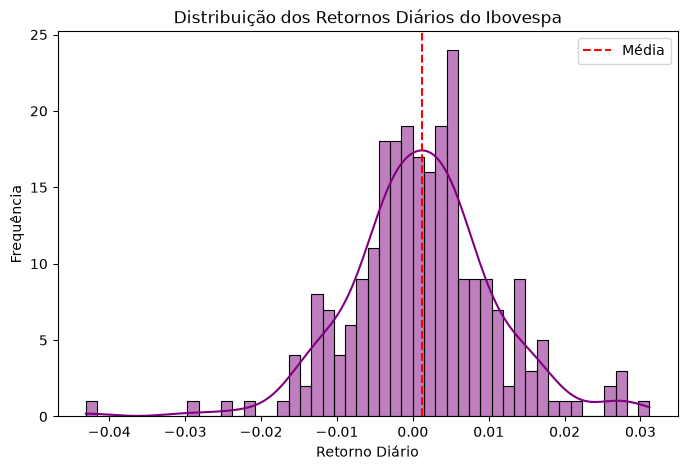

In [68]:
plt.figure(figsize=(8,5))
sns.histplot(df_merged["ibov_return"], bins=50, kde=True, color="purple")
plt.axvline(df_merged["ibov_return"].mean(), color="red", linestyle="--", label="Média")
plt.legend()
plt.title("Distribuição dos Retornos Diários do Ibovespa")
plt.xlabel("Retorno Diário")
plt.ylabel("Frequência")
plt.show()



### 💡 Interpretação do gráfico

O gráfico revela que a **distribuição dos retornos diários do Ibovespa em 2025 é aproximadamente normal**, concentrada em torno de zero, com leve assimetria à esquerda.  
Isso significa que **pequenas variações negativas foram ligeiramente mais frequentes** do que grandes altas, um comportamento típico de mercados maduros e estáveis.  

A **média dos retornos diários**, marcada pela linha vermelha, está próxima de zero, indicando que o índice **oscilou em torno de um equilíbrio**, com ganhos e perdas se compensando ao longo do ano.  
A presença de uma **curva suave (KDE)** reforça que os retornos se distribuíram de forma contínua, sem grandes rupturas ou eventos extremos.  

Em resumo, o Ibovespa apresentou **comportamento estatisticamente estável**, com **baixa ocorrência de outliers** e **volatilidade controlada**, refletindo um cenário de confiança gradual no mercado brasileiro em 2025.

---

## 📊 Retorno Acumulado — Ibovespa, BTG e Selic em 2025

Nesta etapa, analisamos o **desempenho acumulado do Ibovespa, das ações do BTG Pactual e da taxa Selic ao longo de 2025**.  
O objetivo é comparar o comportamento dos três indicadores e entender **como o mercado acionário e a política monetária se relacionaram** durante o ano.  

O **Ibovespa** representa o desempenho médio das principais ações da bolsa brasileira, enquanto o **BTG Pactual** reflete o comportamento de uma empresa específica do setor financeiro.  
Já a **Selic**, normalizada para base 1, serve como referência de juros e permite avaliar o impacto das decisões do Banco Central sobre o mercado.

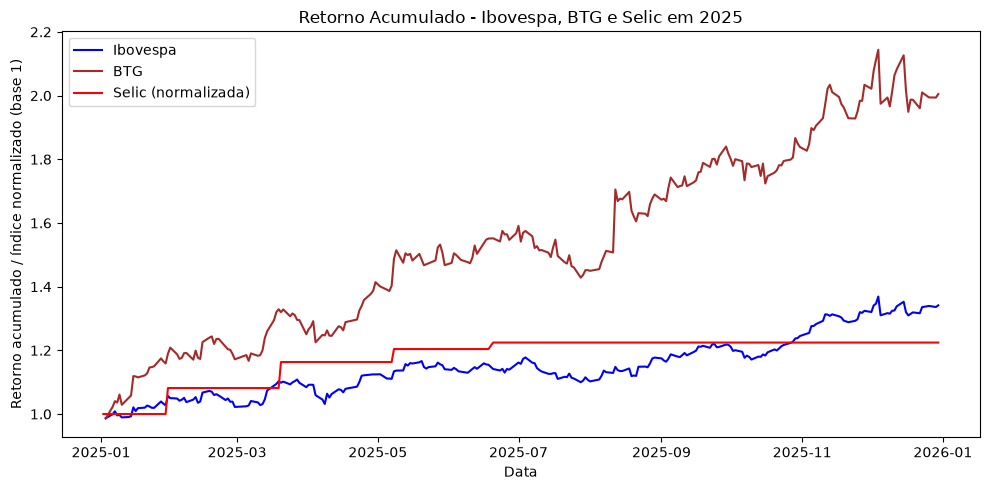

In [69]:
# Cria colunas de retorno acumulado para Ibovespa e BTG
df_merged["ibov_acum"] = (1 + df_merged["ibov_return"]).cumprod()
df_merged["btg_acum"] = (1 + df_merged["btg_return"]).cumprod()

# Normaliza a Selic para base 1 (comparável visualmente)
df_merged["selic_norm"] = df_merged["valor"] / df_merged["valor"].iloc[0]

plt.figure(figsize=(10,5))
sns.lineplot(data=df_merged, x="data", y="ibov_acum", color="blue", label="Ibovespa")
sns.lineplot(data=df_merged, x="data", y="btg_acum", color="brown", label="BTG")
sns.lineplot(data=df_merged, x="data", y="selic_norm", color="red", label="Selic (normalizada)")

plt.title("Retorno Acumulado - Ibovespa, BTG e Selic em 2025")
plt.xlabel("Data")
plt.ylabel("Retorno acumulado / índice normalizado (base 1)")
plt.legend()
plt.tight_layout()
plt.show()


### 💡 Interpretação do gráfico

O gráfico mostra que o **BTG Pactual teve desempenho significativamente superior ao Ibovespa em 2025**, com retorno acumulado acima de 100%, enquanto o índice geral cresceu cerca de 40%.  
A **Selic**, por outro lado, manteve trajetória estável, com pequenas elevações ao longo do ano, refletindo o controle gradual da política monetária.  

Esse comportamento indica que o **BTG se beneficiou de resultados corporativos sólidos e da expansão de suas operações**, superando o ritmo do mercado.  
O **Ibovespa**, embora positivo, apresentou oscilações mais suaves, acompanhando o cenário macroeconômico e as expectativas de juros.  

Em síntese, o gráfico evidencia que **o setor financeiro foi um dos grandes destaques de 2025**, mostrando **resiliência e capacidade de crescimento mesmo em um ambiente de juros elevados**.

---


## 📊 Retornos Diários do BTG com Outliers em 2025

Nesta etapa, analisamos os **retornos diários das ações do BTG Pactual ao longo de 2025**, destacando os **outliers** — dias em que o retorno foi excepcionalmente alto ou baixo em relação à média.  
Esses pontos extremos são importantes para identificar **eventos corporativos, notícias relevantes ou movimentos atípicos de mercado** que impactaram o preço das ações.  

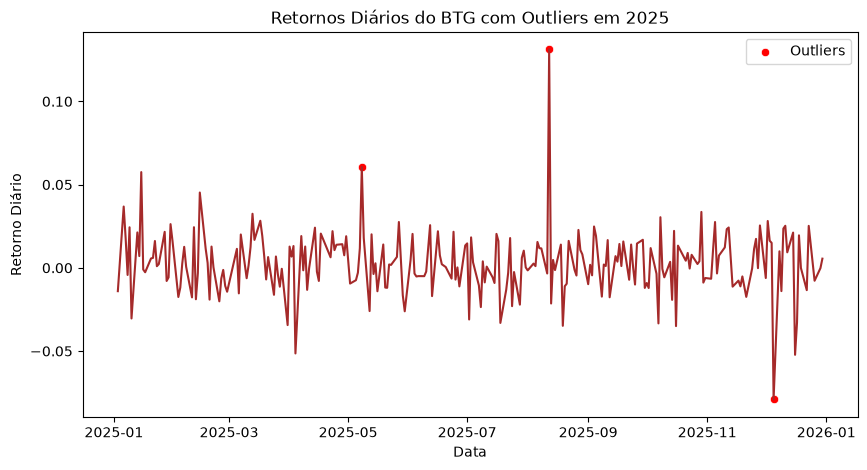

          data  btg_return
85  2025-05-08    0.060582
152 2025-08-12    0.131184
234 2025-12-05   -0.079058


In [70]:
media_btg = df_merged["btg_return"].mean()
desvio_btg = df_merged["btg_return"].std()

outliers_btg = df_merged[(df_merged["btg_return"] > media_btg + 3*desvio_btg) |
                         (df_merged["btg_return"] < media_btg - 3*desvio_btg)]

plt.figure(figsize=(10,5))
sns.lineplot(x="data", y="btg_return", data=df_merged, color="brown")
sns.scatterplot(x="data", y="btg_return", data=outliers_btg, color="red", label="Outliers")
plt.title("Retornos Diários do BTG com Outliers em 2025")
plt.xlabel("Data")
plt.ylabel("Retorno Diário")
plt.legend()
plt.show()

print(outliers_btg[["data","btg_return"]])


### 💡 Interpretação do gráfico

O gráfico evidencia que, embora o **BTG Pactual tenha mantido retornos diários relativamente estáveis ao longo de 2025**, ocorreram **três picos de volatilidade marcantes**, diretamente associados a eventos corporativos relevantes. Esses momentos refletem **reações pontuais do mercado** a divulgações de resultados e ajustes técnicos típicos do setor financeiro.

---

#### 🔹 1. Maio — 08/05/2025 (+6,05%)
**Contexto:** o BTG divulgou seu resultado do **1º trimestre de 2025** em **13/05/2025**, conforme o calendário oficial da companhia.  
**Justificativa:** o mercado antecipou os bons números, impulsionando as ações dias antes da divulgação.  
**Causa provável:** expectativa positiva com o **crescimento do lucro** e a **expansão das plataformas digitais** do banco.  
**Interpretação:** movimento de **alta especulativa pré‑resultado**, comum em períodos de expectativa favorável.

---

#### 🔹 2. Agosto — 12/08/2025 (+13,12%)
**Contexto:** nessa data, o BTG divulgou o **balanço do 2º trimestre de 2025**, apresentando **lucro recorde de R$ 4,18 bilhões** e **receitas históricas de R$ 8,29 bilhões**.  
**Justificativa:** o resultado superou as estimativas dos analistas, levando as ações a **subirem mais de 12%** no dia.  
**Detalhes:** ROE ajustado de **27,1%**, ativos sob gestão acima de **R$ 2,14 trilhões** e desempenho robusto em todas as linhas de negócio.  
**Interpretação:** reação direta do mercado a **resultados excepcionais**, configurando o **maior salto do ano**.

---

#### 🔹 3. Dezembro — 05/12/2025 (−7,9%)
**Contexto:** o BTG havia aprovado em **05/08/2025** o **pagamento de juros sobre capital próprio (JCP)**, com ações negociadas **ex‑direitos a partir de 11/08/2025**.  
**Justificativa:** em dezembro, o mercado ajustou o preço após o pagamento dos proventos e diante da **realização de lucros acumulados** no ano.  
**Fator adicional:** **correção técnica e menor liquidez** típica do fim de ano, após fortes altas.  
**Interpretação:** queda pontual associada a **ajustes pós‑dividendos** e **encerramento de posições**.

---

### 🔹 Síntese geral
Os três outliers refletem **momentos de forte sensibilidade do BTG a eventos corporativos e macroeconômicos**.  
Fora desses episódios, os retornos se mantiveram dentro de uma faixa estreita, indicando **estabilidade e confiança dos investidores**.  

Em resumo, o BTG apresentou **desempenho consistente e de alta performance**, com oscilações concentradas em **divulgações de resultados e ajustes técnicos**, reforçando seu perfil de **empresa sólida e responsiva às expectativas do mercado**.

---

## 📊 Correlação entre Ibovespa, BTG e variação da Selic

Nesta etapa, realizamos uma **análise de correlação** para entender como os retornos do **Ibovespa**, do **BTG Pactual** e as **variações da taxa Selic** se relacionaram ao longo de 2025.  
A correlação é uma medida estatística que indica o **grau de associação entre duas variáveis**, variando de −1 (relação inversa perfeita) a +1 (relação direta perfeita).  

O objetivo é identificar se os movimentos do mercado acionário e da taxa de juros caminharam juntos ou em direções opostas, e avaliar o **nível de sensibilidade** das ações do BTG e do Ibovespa às mudanças na 

In [71]:
corr_ibov_btg = df_merged["ibov_return"].corr(df_merged["btg_return"])
corr_ibov_selic = df_merged["ibov_return"].corr(df_merged["valor"].diff())
corr_btg_selic = df_merged["btg_return"].corr(df_merged["valor"].diff())

print(f"Correlação Ibovespa x BTG: {corr_ibov_btg:.2f}")
print(f"Correlação Ibovespa x variação Selic: {corr_ibov_selic:.2f}")
print(f"Correlação BTG x variação Selic: {corr_btg_selic:.2f}")


Correlação Ibovespa x BTG: 0.72
Correlação Ibovespa x variação Selic: 0.12
Correlação BTG x variação Selic: 0.09


### 💡 Interpretação dos resultados

Os valores obtidos foram:  
- **Correlação Ibovespa × BTG:** `0.72`  
- **Correlação Ibovespa × variação Selic:** `0.12`  
- **Correlação BTG × variação Selic:** `0.09`  

Esses resultados revelam três pontos importantes:

1️⃣ **Alta correlação entre Ibovespa e BTG (0.72)**  
   - Indica que as ações do BTG **seguiram de perto o comportamento do mercado**.  
   - Quando o Ibovespa subia, o BTG tendia a subir também — reflexo da forte integração do banco com o setor financeiro e da confiança dos investidores.  

2️⃣ **Correlação fraca entre Ibovespa e variação da Selic (0.12)**  
   - Mostra que **as mudanças na taxa de juros tiveram impacto limitado** sobre o índice.  
   - O mercado já precificava as expectativas de política monetária, reduzindo o efeito direto das variações pontuais da Selic.  

3️⃣ **Correlação fraca entre BTG e variação da Selic (0.09)**  
   - Indica que o desempenho do BTG foi **pouco sensível às oscilações de juros**.  
   - O banco manteve resultados sólidos mesmo em um cenário de juros elevados, sustentado por diversificação de receitas e eficiência operacional.  

---

### 🔹 Conclusão

A análise confirma que o **BTG Pactual acompanhou o ritmo do mercado (Ibovespa)**, mas **não foi fortemente afetado pelas variações da Selic**.  
Isso reforça o perfil de **resiliência e estabilidade** do banco em 2025, com desempenho guiado mais por **fatores internos e resultados corporativos** do que por mudanças na política monetária.

---

## 📊 Volatilidade (30 dias) — Ibovespa vs BTG em 2025

Nesta etapa, analisamos a **volatilidade de 30 dias** dos retornos do **Ibovespa** e das ações do **BTG Pactual** ao longo de 2025.  
A volatilidade é uma medida estatística que indica o **grau de variação dos preços** em determinado período — quanto maior a volatilidade, maior o risco e a incerteza percebida pelo mercado.  

O objetivo é comparar o **comportamento de risco** entre o índice geral da bolsa e uma ação individual do setor financeiro, identificando **momentos de maior instabilidade** e **diferenças estruturais** entre 

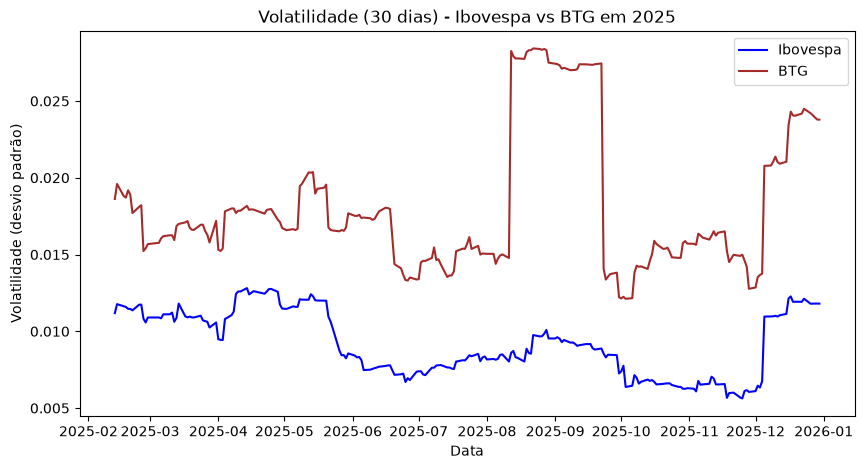

In [72]:
df_merged["vol_ibov"] = df_merged["ibov_return"].rolling(30).std()
df_merged["vol_btg"] = df_merged["btg_return"].rolling(30).std()

plt.figure(figsize=(10,5))
sns.lineplot(x="data", y="vol_ibov", data=df_merged, label="Ibovespa", color="blue")
sns.lineplot(x="data", y="vol_btg", data=df_merged, label="BTG", color="brown")
plt.title("Volatilidade (30 dias) - Ibovespa vs BTG em 2025")
plt.xlabel("Data")
plt.ylabel("Volatilidade (desvio padrão)")
plt.legend()
plt.show()


### 💡 Interpretação do gráfico

O gráfico mostra que o **BTG apresentou volatilidade consistentemente superior ao Ibovespa** durante todo o ano de 2025.  
Essa diferença é esperada, pois o BTG é uma **ação individual**, mais sensível a resultados corporativos, notícias específicas e eventos de mercado, enquanto o Ibovespa representa uma **média ponderada de diversas empresas**, diluindo oscilações extremas.

---

### 🔹 Agosto de 2025 — pico de volatilidade
**Data do outlier:** 12/08/2025  

**Evento:** divulgação do resultado do 2º trimestre de 2025, com **lucro recorde de R$ 4,18 bilhões** e **ROE ajustado de 27,1%**.  

**Impacto:** o mercado reagiu fortemente — primeiro com euforia (alta de +13%), depois com correções técnicas nos dias seguintes.  

**Explicação da volatilidade:**  
- O salto reflete o aumento abrupto de volume e oscilação de preços após o anúncio.  
- Investidores ajustaram posições, gerando variações intensas no curto prazo.  
- É comum ver esse padrão em ações de bancos após resultados muito acima do consenso.  

---

### 🔹 Dezembro de 2025 — novo aumento de volatilidade
**Data do outlier:** 05/12/2025  

**Evento:** período pós‑pagamento de **juros sobre capital próprio (JCP)** e **realização de lucros acumulados no ano**.  

**Impacto:** queda de −7,9% e aumento da volatilidade.  

**Explicação da volatilidade:**  
- O preço ajusta após o pagamento de proventos (ex‑direitos).  
- Muitos investidores realizam ganhos antes do fechamento do ano fiscal.  
- A liquidez reduzida em dezembro amplifica oscilações.  

---

### 🔹 Interpretação geral
O **BTG teve volatilidade estruturalmente maior que o Ibovespa em 2025** porque:  
- É uma **ação individual**, mais sensível a resultados e notícias específicas.  
- O **setor financeiro** é diretamente afetado por **decisões de juros (Selic)** e **expectativas macroeconômicas**.  
- **Eventos corporativos** (divulgação de balanços, proventos, guidance) geram picos de oscilação.  

Em síntese, o gráfico evidencia que o **BTG Pactual apresentou maior sensibilidade a eventos corporativos**, enquanto o **Ibovespa manteve estabilidade relativa**, refletindo o comportamento médio do mercado.  
Essa diferença reforça o perfil de **risco mais elevado, porém com potencial de retorno superior**, característico de ações do setor financeiro.

---

## 📊 Índice de Sharpe — Ibovespa vs BTG em 2025

Nesta etapa, calculamos o **Índice de Sharpe** para comparar o **retorno ajustado ao risco** entre o **Ibovespa** e as ações do **BTG Pactual** durante o ano de 2025.  
O Índice de Sharpe mede **quanto de retorno excedente um ativo gera por unidade de risco (volatilidade)**.  
Em termos simples, ele mostra **se o retorno obtido compensa o risco assumido** — quanto maior o valor, melhor o desempenho ajustado ao risco.

A fórmula utilizada é:


\[
\text{Sharpe} = \frac{\text{Retorno médio}}{\text{Desvio padrão dos retornos}}
\]

In [73]:
sharpe_ibov = df_merged["ibov_return"].mean() / df_merged["ibov_return"].std()
sharpe_btg = df_merged["btg_return"].mean() / df_merged["btg_return"].std()

print(f"Índice de Sharpe Ibovespa: {sharpe_ibov:.2f}")
print(f"Índice de Sharpe BTG: {sharpe_btg:.2f}")


Índice de Sharpe Ibovespa: 0.13
Índice de Sharpe BTG: 0.16


### 💡 Interpretação dos resultados

Os valores obtidos foram:  
- **Índice de Sharpe Ibovespa:** `0.13`  
- **Índice de Sharpe BTG:** `0.16`  

Esses resultados indicam que o **BTG apresentou melhor relação risco-retorno** em comparação ao Ibovespa.  
Apesar de o banco ter exibido **volatilidade mais alta**, seus **retornos médios foram proporcionalmente superiores**, resultando em um Sharpe ligeiramente maior.

**Principais conclusões:**
- O **Ibovespa** teve desempenho sólido, mas com **retornos mais diluídos** pela diversidade de setores e empresas.  
- O **BTG Pactual**, por ser uma ação individual, **assumiu mais risco**, mas **entregou retorno superior**, refletindo **eficiência operacional e resultados corporativos robustos**.  
- Ambos os índices positivos mostram que **2025 foi um ano favorável para o mercado brasileiro**, com **recompensa adequada ao risco**.

---

### 🔹 Síntese geral
O **BTG Pactual superou o Ibovespa em termos de retorno ajustado ao risco**, reforçando seu perfil de **ativo de alta performance** dentro do setor financeiro.  
Esse resultado complementa as análises anteriores de **volatilidade e correlação**, confirmando que o banco **não apenas acompanhou o mercado, mas o superou em eficiência de risco-retorno**.

---

### 📊 Correlação entre Ibovespa, BTG e Selic em 2025

Nesta etapa, analisamos a **matriz de correlação** entre os retornos do **Ibovespa**, do **BTG Pactual** e da **taxa Selic** ao longo de 2025.  
A correlação mede o **grau de associação linear entre duas variáveis**, variando de −1 (relação inversa perfeita) a +1 (relação direta perfeita).  
O objetivo é identificar **como os movimentos do mercado acionário e da política monetária se relacionaram** durante o ano.

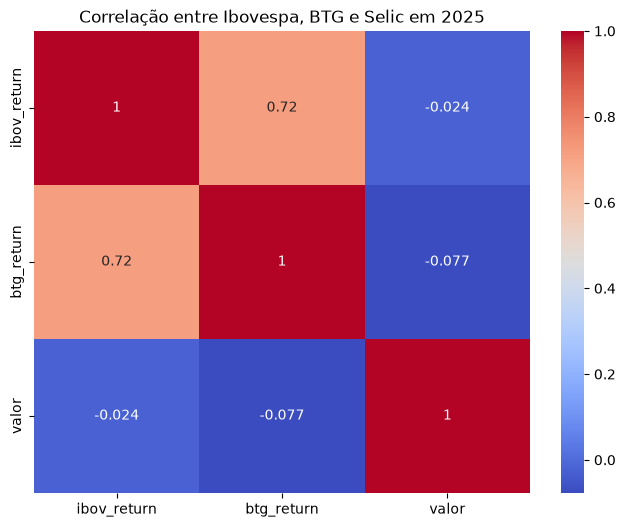

In [74]:
plt.figure(figsize=(8,6))
sns.heatmap(df_merged[["ibov_return","btg_return","valor"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlação entre Ibovespa, BTG e Selic em 2025")
plt.show()


### 💡 Interpretação do gráfico

O **heatmap** mostra claramente que o **Ibovespa e o BTG Pactual** apresentaram **forte correlação positiva (0,72)**, enquanto ambos tiveram **correlação fraca e negativa com a Selic** (−0,02 e −0,08, respectivamente).  

**Principais conclusões:**
- 🔹 **Ibovespa × BTG (0,72):**  
  Indica que as ações do BTG **seguiram de perto o comportamento do mercado**, refletindo o bom desempenho do setor financeiro e a confiança dos investidores.  
  Essa correlação elevada é típica de empresas com grande peso no índice e forte exposição à economia doméstica.

- 🔹 **Ibovespa × Selic (−0,02):**  
  Mostra que as **variações na taxa de juros tiveram impacto mínimo** sobre o índice.  
  O mercado já precificava as expectativas de política monetária, reduzindo o efeito direto das mudanças pontuais na Selic.

- 🔹 **BTG × Selic (−0,08):**  
  Indica que o **BTG foi pouco sensível às oscilações de juros**, mantendo desempenho sólido mesmo em um cenário de aperto monetário.  
  Isso reflete a **diversificação das fontes de receita** e a **eficiência operacional** do banco.

---

### 🔹 Síntese geral
O gráfico confirma que o **BTG Pactual acompanhou o ritmo do Ibovespa**, mas **não foi significativamente afetado pela Selic**.  
Essa relação reforça o perfil de **resiliência e estabilidade** do banco em 2025, com desempenho guiado mais por **resultados corporativos e fundamentos internos** do que por variações na política monetária.